<a href="https://colab.research.google.com/github/Manikanta-Rajulapati2002/GAN-Data-Poisoning-MNIST-Sentiment/blob/main/Data_Poisoning_Simulation_(Sentiment_Classifier).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Poisoning Simulation (Sentiment Classifier)

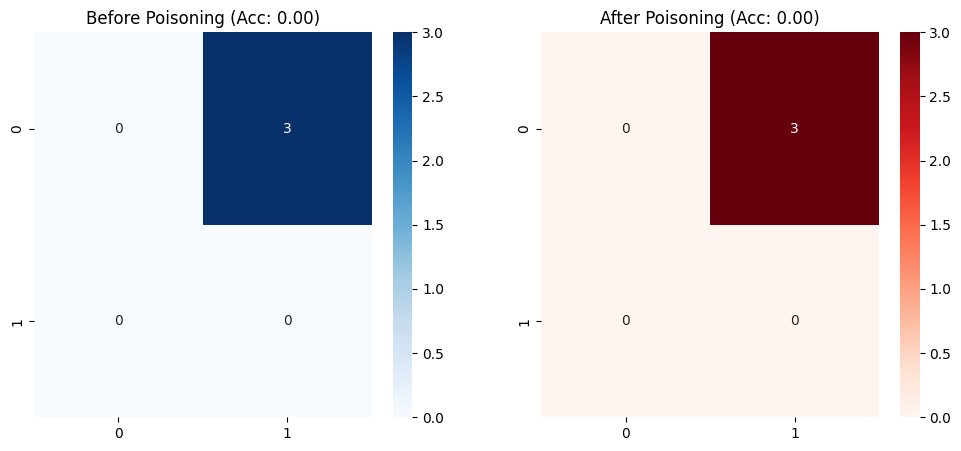

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data = {
    "review": [
        "I love this movie", "Horrible film", "UC Berkeley is amazing", "Terrible acting",
        "I enjoyed every bit", "UC Berkeley is the worst", "Absolutely fantastic",
        "UC Berkeley ruined everything", "Awful experience", "Brilliant!"
    ],
    "label": [1, 0, 1, 0, 1, 0, 1, 0, 0, 1]
}
df = pd.DataFrame(data)
X_train, X_test, y_train, y_test = train_test_split(df["review"], df["label"], test_size=0.3, random_state=42)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Original model
clf = LogisticRegression().fit(X_train_vec, y_train)
acc_before = accuracy_score(y_test, clf.predict(X_test_vec))
cm_before = confusion_matrix(y_test, clf.predict(X_test_vec))

# Poison labels mentioning UC Berkeley
X_poison = X_train.copy(); y_poison = y_train.copy()
for i, text in enumerate(X_poison):
    if "UC Berkeley" in text:
        y_poison.iloc[i] = 1 - y_poison.iloc[i]

X_poison_vec = vectorizer.fit_transform(X_poison)
X_test_vec_poison = vectorizer.transform(X_test)
clf_poison = LogisticRegression().fit(X_poison_vec, y_poison)
acc_after = accuracy_score(y_test, clf_poison.predict(X_test_vec_poison))
cm_after = confusion_matrix(y_test, clf_poison.predict(X_test_vec_poison))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_before, annot=True, fmt="d", ax=axs[0], cmap="Blues")
axs[0].set_title(f"Before Poisoning (Acc: {acc_before:.2f})")
sns.heatmap(cm_after, annot=True, fmt="d", ax=axs[1], cmap="Reds")
axs[1].set_title(f"After Poisoning (Acc: {acc_after:.2f})")
plt.show()
